# DZO Assignment: Essentials of Fourier Transform in 2D

In this assignment, we will have a look at the relationship between the image in spatial domain and its Fourier transform in the frequency domain. We will be using the Discrete Fourier transform which is available in the `numpy` package - the `np.fft.fft2` function for the direct transform and  `np.fft.ifft2` for the inverse. The corresponding DFT formulas are 
$$
F(u, v) = \sum_{x=0}^{N-1} \sum_{y=0}^{M-1} f(x, y) e^{-2\pi i \left(\frac{u x}{N} + \frac{v y}{M}\right)}
$$
for the direct transform and 
$$
f(x, y) = \frac{1}{MN}\sum_{u=0}^{N-1} \sum_{v=0}^{M-1} F(u, v) e^{2\pi i \left(\frac{u x}{N} + \frac{v y}{M}\right)}
$$
for the inverse, where $f(x,y)$ is the image and $F(u, v)$ is its Fourier transform (and $M$ and $N$ are height and width of the image, respectively.) 

The `numpy.fft` module includes further useful functions like e.g. `np.fft.fftshift` which is used for shifting the frequencies or viewing so that the DC component is at the centre (as opposed to the result of `np.fft.fft2` where the DC component, in agreement with the DFT definition, is at the top-left corner.)

In [1]:
%load_ext autoreload
%autoreload 2

from fourier import *
from DZO.utils import load_test_image, imread

import numpy as np
import matplotlib.pyplot as plt

# set the default fixed size for figures so that they are not as big as the default:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (3,3)

First of all, make sure you can use all the FFT functions. Type this yourself (as opposed to copy-pasting it) and observe the results: 

Text(0.5, 1.0, 'magnitude spectrum')

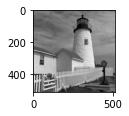

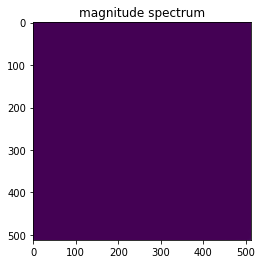

In [2]:
from numpy.fft import fft2, ifft2, fftshift, ifftshift
im = load_test_image('lighthouse.png').mean(axis=2)
IM = fft2(im)

# let us display the image: 
plt.figure(figsize=(1.5,1.5)); plt.imshow(im, cmap='gray')

# let us display the amplitude spectrum: 
plt.figure()
plt.imshow( abs(IM) ); plt.title('magnitude spectrum')

Not much visible there. Are all values in the image very close? No, on the contrary. The range of values is very high: 

Text(0.5, 1.0, 'histogram of log(1+abs(IM))')

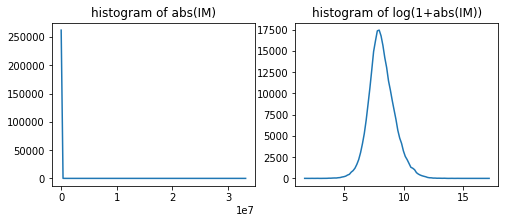

In [3]:
hist, bin_edges = np.histogram(abs(IM), bins = 100)
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(bin_edges[:-1], hist); plt.title('histogram of abs(IM)')
# that shows that majority of pixels contain low values.  

# let's take a log: 
hist, bin_edges = np.histogram(np.log( 1+abs(IM) ), bins = 100)
plt.subplot(1,2,2)
plt.plot(bin_edges[:-1], hist); plt.title('histogram of log(1+abs(IM))')

So, when showing the magnitude spectrum let's display the log of absolute value of FFT: 

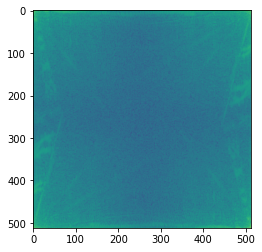

In [4]:
plt.imshow(np.log(0.1+abs(IM)))

That shows the magnitude spectrum with the DC component (centre of the magnitude spectrum) at the top left corner. To position the centre of the spectrum to the centre of the image, we use the `fftshift`: 

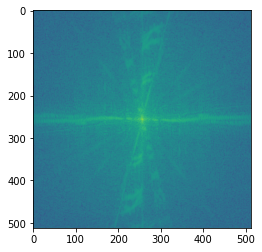

In [5]:
plt.imshow( fftshift( np.log(0.1 + abs(IM)) ) )

Now we'll look into FFT for various inputs in detail. 

### Implementing image generator 
Your first task is to implement an image generator which will produce different basic 2D signals. These signals will serve as toy images for which FFT will be computed and important relationships between spatial and frequency domains will be observed.

We'll start with a square image of size only `5x5`: (make sure you have a look at functions show_FT_triplet and show_FT_pair so that you know what they are doing)

image: min=0.0e+00, max=1.0e+00.


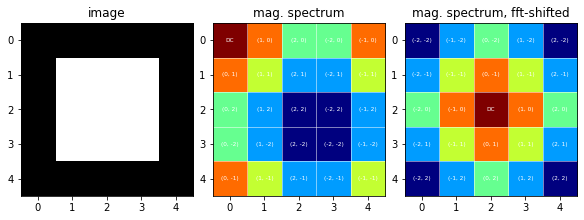

In [6]:
im = image_generator('square', (5, 5), half_side = 1)
# (see the template for specs of output of image_generator)

# this is the function prepared in fourier.py and which you do not have to implement. 
show_FT_triplet(im, show_frequency_labels = True)


And observe where the DC component goes when the size of the image is even:

image: min=0.0e+00, max=1.0e+00.


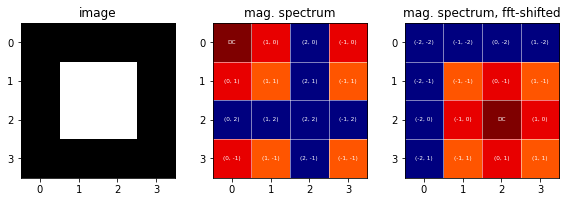

In [7]:
im = image_generator('square', (4, 4), half_side = 1)
show_FT_triplet(im, show_frequency_labels = True)

Let us now have a look at an image of a function which has the form very similar to Fourier basis functions. That is why when we make the Fourier transform of it, we get two nice points with nonzero values.

image: min=-8.1e-01, max=1.0e+00.


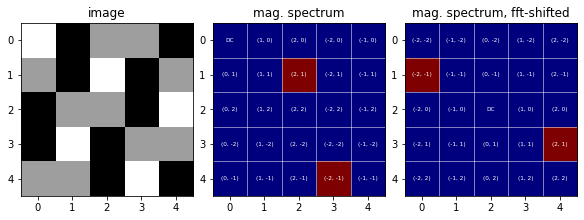

In [8]:
im = image_generator('harmonic', (5, 5), u=2, v=1, phi=0)
show_FT_triplet(im, show_frequency_labels = True)

image: min=-1.0e+00, max=1.0e+00.


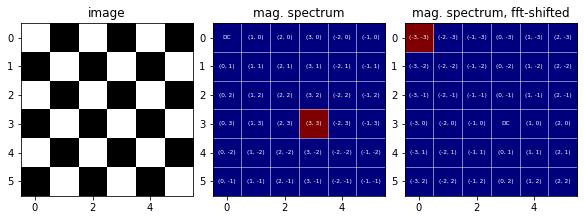

In [9]:
# And how about the image coresponding to Nyquist frequency in both x and y directions? 
im = image_generator('harmonic', (6, 6), u=3, v=3, phi=0)
show_FT_triplet(im, show_frequency_labels = True)

Let us see examples of image generators for various settings choices: 

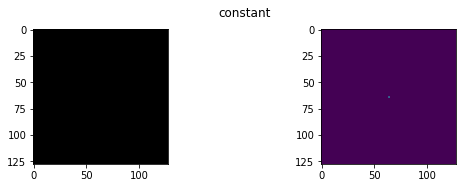

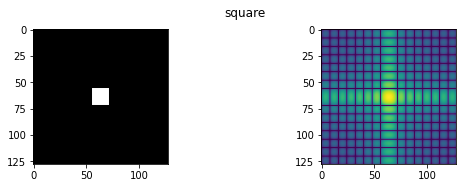

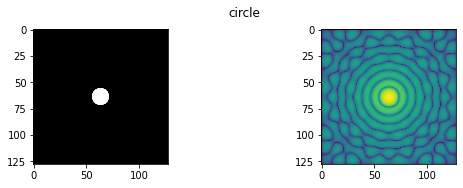

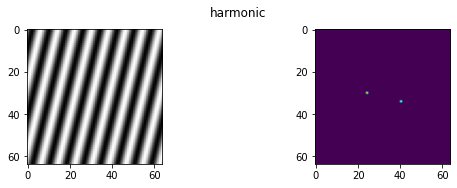

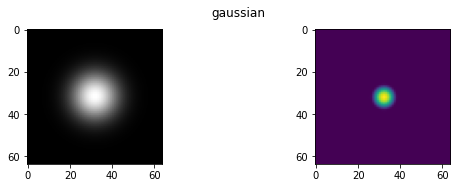

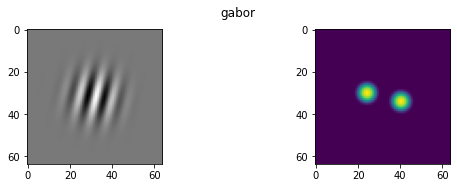

In [10]:
# set default figsize for all the image we'll be showing

im = image_generator('constant', (128, 128), value = 3.0)
show_FT_pair(im, fig_title = 'constant')

im = image_generator('square', (128, 128), half_side = 8)
show_FT_pair(im, fig_title='square')

im = image_generator('circle', (128, 128), radius = 8)
show_FT_pair(im, fig_title='circle')

im = image_generator('harmonic', (64, 64), u = 8, v = 2, phi = np.pi/2)
show_FT_pair(im, fig_title='harmonic')

im = image_generator('gaussian', (64, 64), sigma = 7.5)
show_FT_pair(im, fig_title='gaussian')

im = image_generator('gabor', (64, 64), sigma = 7.5, u = 8, v = 2, phi = 0.0)
show_FT_pair(im, fig_title='gabor')



## Dependence of FT on translation and rotation
Let us now observe how the FT changes when an image is translated or rotated. 
Let us start with translation. 

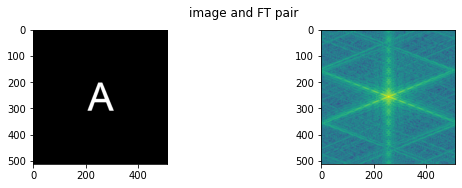

In [11]:
im = imread('A_black.png')
show_FT_pair(im)

Now translate it by 100 pixels and compare its magnitude spectrum to the original: 

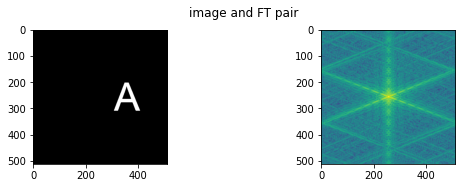

In [12]:
im_t = np.c_[ im[:, -100:], im[:, :-100] ]
show_FT_pair(im_t)

We can see that translation does not change the magnitude spectrum. Lets show the difference in phase of the two images: 

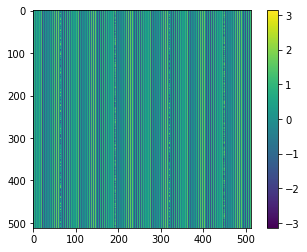

In [13]:
IM = fft2(im)
IM_t = fft2(im_t)
plt.imshow(np.angle( IM_t / IM )) 
plt.colorbar()

Let us now observe how the spectrum changes with rotation. An image of letter A rotated by 90 is easily obtained by transposition: 

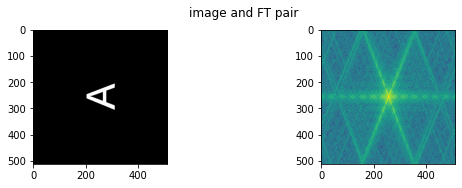

In [14]:
im_r = im.T
show_FT_pair(im_r)

Additionally, let us load an image of letter A rotated by 45 degrees and observe its FT. 

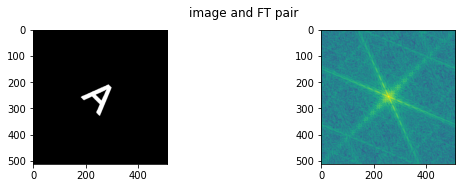

In [15]:
im_r = imread('A_black_45.png')
show_FT_pair(im_r)

We can see that the magnitude spectrum rotates with the image itself. 

## Low / high pass filtering in frequency domain 

Frequency domain can be used to filter high / low frequencies. 

Let us start with low pass filtering. The result such filtering will be a blurred image. 

Try this yourself on a test image:


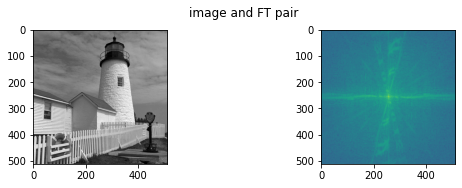

In [16]:
im = load_test_image('lighthouse.png').mean(axis=2)
show_FT_pair(im)


Create an unnormalized Gaussian (the one whose max intensity is `1.0`) with e.g. `sigma=20`. 
Note you may even use your `image_generator` function for that, in conjunction with a shifting function (`fftshift` or  `ifftshift`). Note that for fully correct result, you must ensure the DC component corresponds to the center of the Gaussian. 


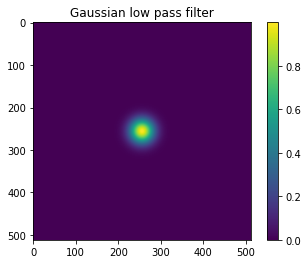

In [17]:
sigma = 20
G = image_generator('gaussian', im.shape, sigma=sigma)

plt.imshow(G)
plt.colorbar()
plt.title('Gaussian low pass filter')
plt.show()

Filtering in the frequency domain is just multiplication by the filter. The original spectrum, multiplied by the Gaussian, looks like this (shown using `np.log` as usual): 

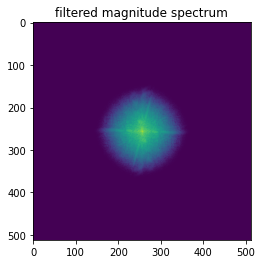

In [18]:
im_fft = np.fft.fftshift(np.fft.fft2(im))

filtered_fft = im_fft * G

plt.imshow(np.log(0.1 + np.abs(filtered_fft)))
plt.title('filtered magnitude spectrum')
plt.show()


Now we take IFFT and get the filtered image: 

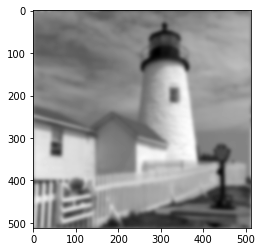

In [19]:
im_back = np.fft.ifft2(np.fft.ifftshift(filtered_fft))

im_filtered = np.abs(im_back)

plt.imshow(im_filtered, cmap='gray')
plt.show()

We can do exactly the same processing for high-pass filtering, only with a suitable filter. 
An easy choice is to use `1.0-G` as the high pass filter, where `G` is the unnormalized Gaussian from the above task. Then the filtered spectrum looks like this: 

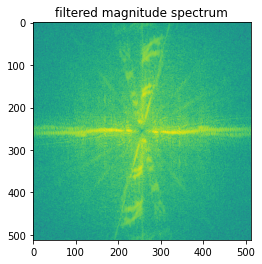

In [20]:
hpf = 1.0 - G

hpf_fft_centered = im_fft * hpf

plt.imshow(np.log(0.1 + np.abs(hpf_fft_centered)))
plt.title('filtered magnitude spectrum')
plt.show()


and the result of filtering is: 

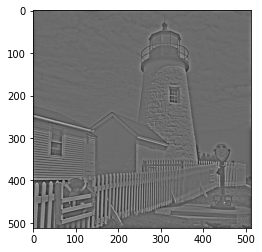

In [21]:
im_hpf_back = np.fft.ifft2(np.fft.ifftshift(hpf_fft_centered))

im_hpf_result = np.real(im_hpf_back)

plt.imshow(im_hpf_result, cmap='gray')
plt.show()

Make sure you can produce such results and understand the underlying principles. 

## Computing measure of directionality in an image from its spectrum 

Based on your understanding of Fourier spectrum, implement the function `measure_dominant_direction`. This will include coming up with an idea for an algorithm. The following text will illustrate what the problem is about and give you the required background for solving this task. 

Let us take a real image. It is taken from the [Curet dataset]( https://www.cs.columbia.edu/CAVE/software/curet/ ), sample 38, illumination and viewing directions 01, 28. The original name of the file is `38-01-28.png`. This image has been cropped and saved as sample38.png . You can work with it below. 


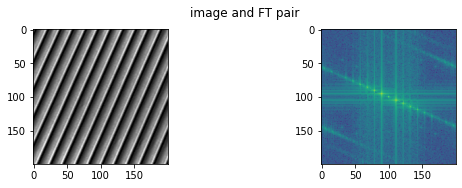

In [22]:
im = imread('sample38.png', convert_to_gray=True)
show_FT_pair(im)

The directionality is clearly visible in the spectrum. But besides that, there is a lot of large magnitude frequencies which are caused by image borders. That's because the FFT 'sees' the image as if the whole 2D plane would've been tiled with it: 
![tiled image](./assets/sample38tiled.png)

To reduce the impact of image boundaries, it often helps to first apply a smooth windowing function to an image and only then to apply the Fourier transform. You will implement a `cosine_envelope` function which is a product of two 1D cosine windowinf functions, $w(x)$ and $w(y)$. Each of the functions have the same form  $w(p) = \frac{1}{2}(1+cos(p \omega))$ where $\omega$ is a constant selected so that the function is cyclically periodic. The function is positioned so that its maximum is at the centre and minimum is at the borders. The following images illustrate that better than words: 

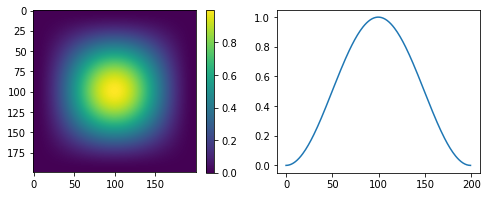

In [23]:
envelope = cosine_envelope(im.shape)
[M, N] = im.shape

plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1); plt.imshow(envelope); plt.colorbar()
plt.subplot(1, 2, 2); plt.plot(envelope[M//2, :])

Let us now apply such envelope to the image. 

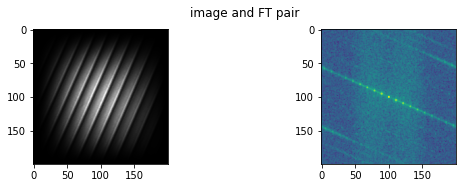

In [24]:
im_e = im * envelope
show_FT_pair(im_e)

The FT image is now much cleaner. 

Your task is now to suggest a principle on which to build the function measure_dominant_orientation. 
The example of working implementation is below. 

In [32]:
# phi, measure = measure_dominant_orientation(im)
# plt.plot(phi, measure); plt.xlabel('phi'); plt.ylabel('directionality')
# phi_max = phi[np.argmax(measure)]
# print(f"Maximum directionality is at {phi_max/np.pi*180:.2f} deg") 
# print("This angle is a standard polar angle measure from x axis towards the positive y-axis.")
# print("The positive direction of y axis in an image is downwards.")
def measure_dominant_orientation(im):
    # Временная заглушка, чтобы тест не ругался на отсутствие функции
    return np.linspace(0, np.pi, 360), np.zeros(360)


Above is the dependence of measure of directionality on angle. The reference system for the angle is described above in the code cell. Also see the following code where the dominant orientation and the direction perpendicular to it are plotted in blue and red, respectively. 


In [33]:
# # Display the maximum of directionality 
# plt.imshow(im, cmap = 'gray')
# cx, cy = [el//2 for el in im.shape[::-1]]
# R = min(cx, cy) - 3
# plt.plot((cx, cx+R*np.cos(phi_max)), (cy, cy + R*np.sin(phi_max)), 'b')
# plt.plot((cx, cx+R*np.cos(phi_max + np.pi/2)), (cy, cy + R*np.sin(phi_max + np.pi/2)), 'r')


## Submission to BRUTE 

Implement the required functions `image_generator`, `cosine_envelope` and `measure_dominant_orientation`. 
Submit both your `fourier.py` and `fourier.ipynb` files (zipped) to BRUTE.  

